# CNN (ImageNet-VGG16) representations

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

device = get_device()
print(f"device = {device}")
if device == 'cpu':
    print("NOTE: CNN cells will be slow on CPU. A GPU runtime is recommended.")


device = cuda


In [4]:
_c = load_cache('01_stimulus_construction')
face_subset = _c['face_subset']
house_subset = _c['house_subset']
avg_mag_all = _c['avg_mag_all']


In [5]:
# @title Cache raw per-image CNN activations (ImageNet VGG16, 7 layers, all 42 conditions)

cnn = models.vgg16(weights='IMAGENET1K_V1').to(device).eval()

activations = {}
ec.register_vgg_hooks(cnn, activations)

preprocess = ec.get_cnn_preprocess()

N_SEEDS = 3   # phase-scramble seeds per image; 38-image averaging already dominates stabilization

raw_cnn_acts = ec.cache_raw_cnn_activations(cnn, activations, layer_names, face_subset, house_subset,
                                             avg_mag_all, preprocess, device, n_seeds=N_SEEDS)

print(f"\nTotal forward passes: {2 * len(NOISE_LEVELS) * n_stim * N_SEEDS}")
print(f"Cache shape per (layer, condition): ({n_stim*N_SEEDS}, n_units)")


face: all 21 noise levels cached


house: all 21 noise levels cached

Total forward passes: 4788
Cache shape per (layer, condition): (114, n_units)


In [6]:
# @title Build primary CNN layer RDMs (crossnobis) + bootstrap stability check

cnn_layer_rdms_primary = {L: build_layer_rdm_crossnobis(raw_cnn_acts, L) for L in layer_names}
print("Primary CNN layer RDMs built (crossnobis, from cached activations).")

N_BOOTSTRAPS, N_TRIALS_MATCH = 20, 15
cnn_layer_rdms_bootstrap = {L: [] for L in layer_names}
for b in range(N_BOOTSTRAPS):
    rdms_b = build_layer_rdms_bootstrap_once(raw_cnn_acts, layer_names, CONDITIONS, N_TRIALS_MATCH, bootstrap_seed=b)
    for L in layer_names:
        cnn_layer_rdms_bootstrap[L].append(rdms_b[L])
print(f"{N_BOOTSTRAPS} bootstrap RDMs built per layer (matched to ~{N_TRIALS_MATCH} trials/condition).")

print("\nStability check (Spearman r, primary vs. bootstrap-mean RDM):")
for L in layer_names:
    boot_mean_rdm = np.nanmean(cnn_layer_rdms_bootstrap[L], axis=0)
    r, p = stats.spearmanr(upper_tri(cnn_layer_rdms_primary[L]), upper_tri(boot_mean_rdm), nan_policy='omit')
    print(f"  {L}: r={r:.3f}")


Primary CNN layer RDMs built (crossnobis, from cached activations).


20 bootstrap RDMs built per layer (matched to ~15 trials/condition).

Stability check (Spearman r, primary vs. bootstrap-mean RDM):
  pool1: r=0.999
  pool2: r=0.999
  pool3: r=1.000
  pool4: r=0.999
  pool5: r=0.998
  fc6: r=0.999
  fc7: r=0.999


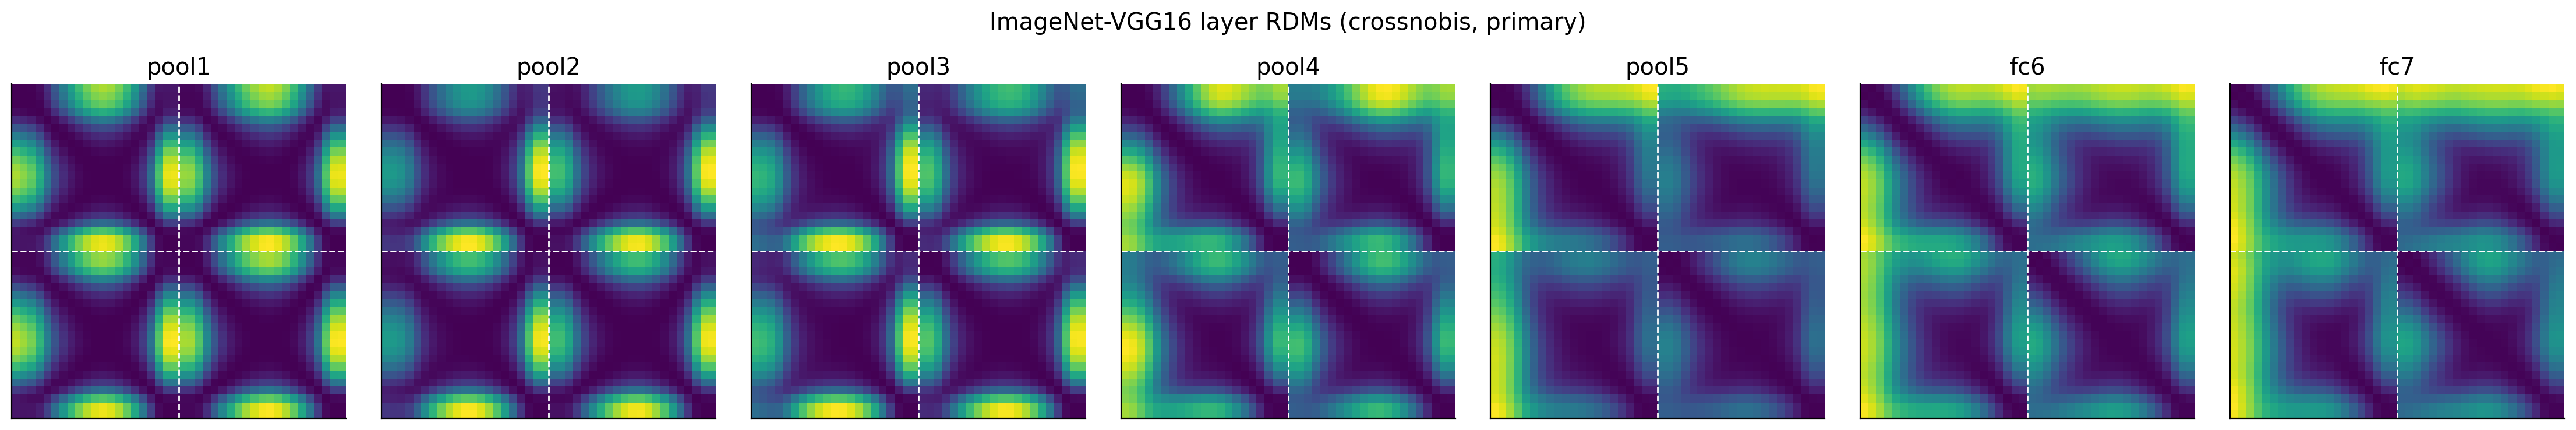

In [7]:
# @title CNN layer RDM heatmaps (category-major ordering)

fig, axes = plt.subplots(1, len(layer_names), figsize=(3.2*len(layer_names), 3.6))
for ax, L in zip(axes, layer_names):
    rdm_cat = reorder_rdm(cnn_layer_rdms_primary[L], perm)
    ax.imshow(rdm_cat, cmap='viridis')
    ax.axvline(len(NOISE_LEVELS)-0.5, color='white', lw=1, ls='--')
    ax.axhline(len(NOISE_LEVELS)-0.5, color='white', lw=1, ls='--')
    ax.set_title(L); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('ImageNet-VGG16 layer RDMs (crossnobis, primary)', y=1.02)
plt.tight_layout(); display(Image(save_fig(fig, '05_cnn_representations_fig01'))); plt.close(fig)


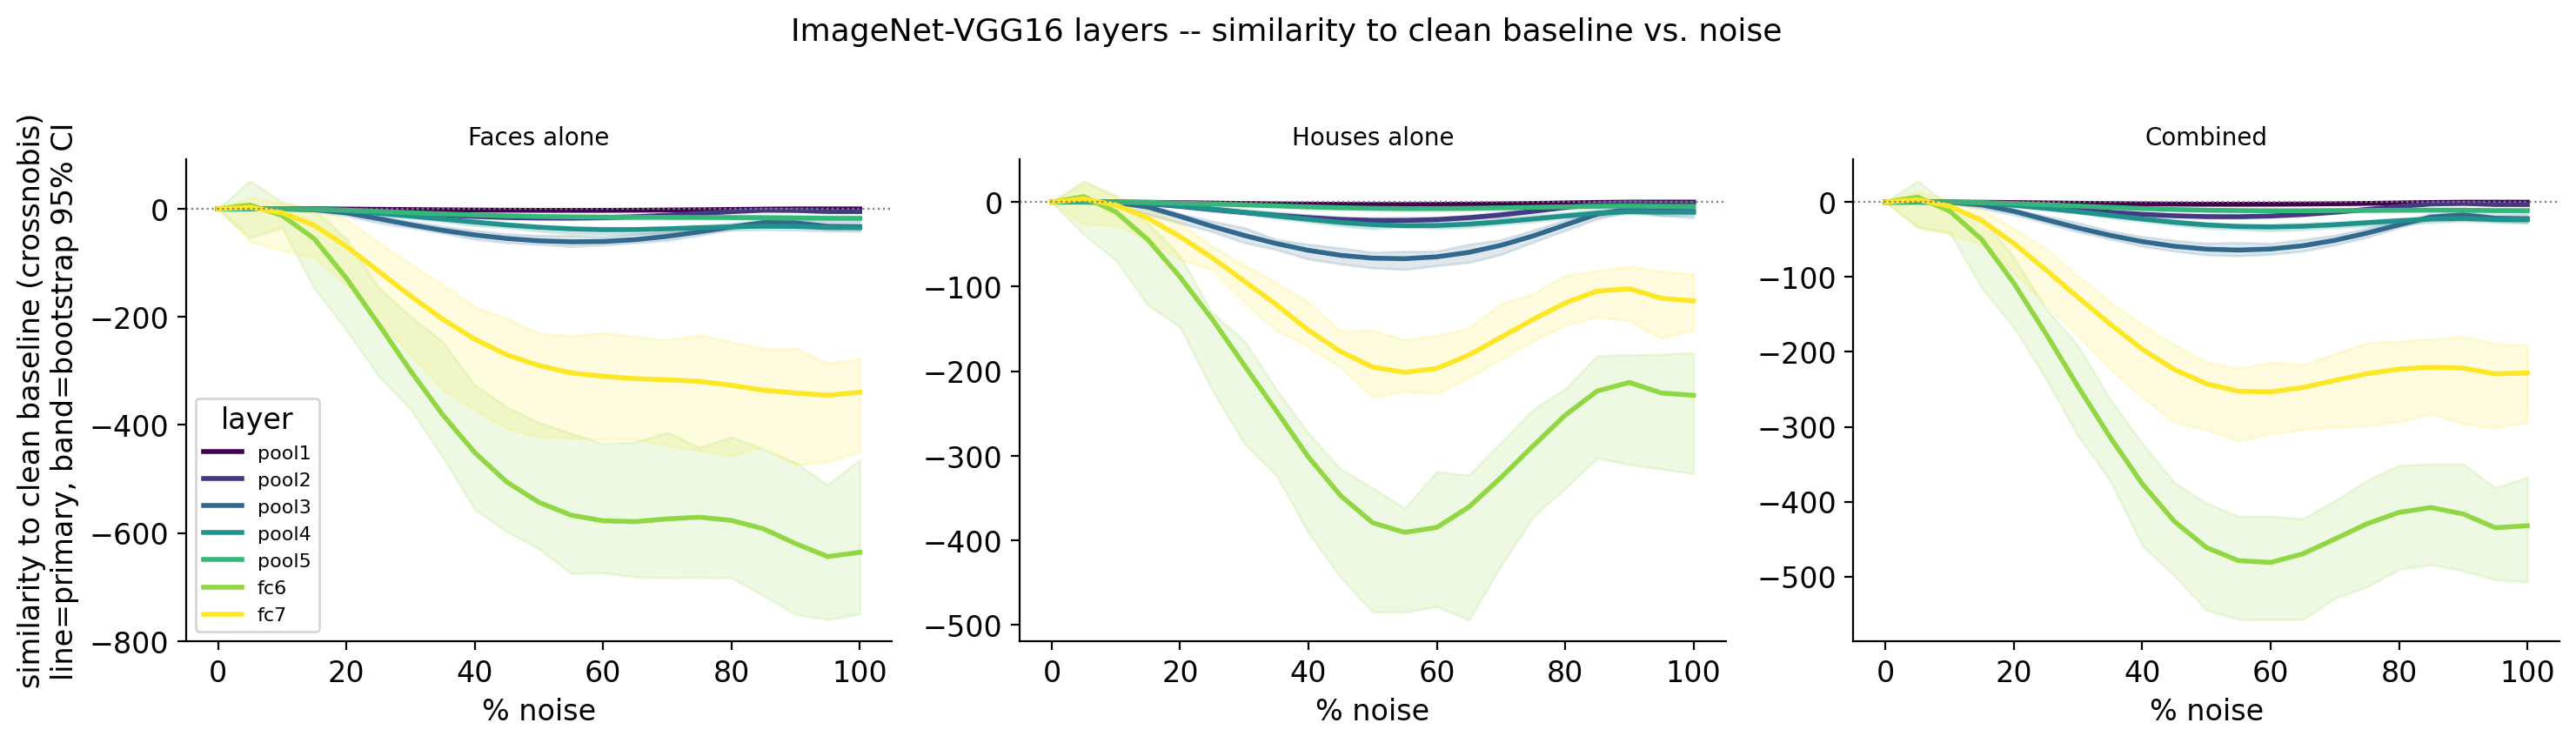

Combined-metric similarity at 50% noise, per layer:
  pool1: -2.844
  pool2: -19.354
  pool3: -62.758
  pool4: -30.464
  pool5: -10.792
  fc6: -461.240
  fc7: -242.583


In [8]:
# @title CNN similarity-to-baseline curves, overlay layers, with bootstrap 95% CI band

layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panel_titles = ['Faces alone', 'Houses alone', 'Combined']
theta_report = {}
for L, c in zip(layer_names, layer_colors):
    rdm = cnn_layer_rdms_primary[L]
    sim_face, sim_house = similarity_to_baseline(rdm, 'face'), similarity_to_baseline(rdm, 'house')
    sim_comb = np.nanmean(np.vstack([sim_face, sim_house]), axis=0)
    axes[0].plot(NOISE_LEVELS, sim_face, '-', color=c, label=L, lw=2)
    axes[1].plot(NOISE_LEVELS, sim_house, '-', color=c, lw=2)
    axes[2].plot(NOISE_LEVELS, sim_comb, '-', color=c, lw=2)

    boot_face = np.array([similarity_to_baseline(r, 'face') for r in cnn_layer_rdms_bootstrap[L]])
    boot_house = np.array([similarity_to_baseline(r, 'house') for r in cnn_layer_rdms_bootstrap[L]])
    boot_comb = np.nanmean(np.stack([boot_face, boot_house]), axis=0)
    lo_f, hi_f = np.nanpercentile(boot_face, [2.5, 97.5], axis=0)
    lo_h, hi_h = np.nanpercentile(boot_house, [2.5, 97.5], axis=0)
    lo_c, hi_c = np.nanpercentile(boot_comb, [2.5, 97.5], axis=0)
    axes[0].fill_between(NOISE_LEVELS, lo_f, hi_f, color=c, alpha=0.15)
    axes[1].fill_between(NOISE_LEVELS, lo_h, hi_h, color=c, alpha=0.15)
    axes[2].fill_between(NOISE_LEVELS, lo_c, hi_c, color=c, alpha=0.15)
    theta_report[L] = float(sim_comb[np.argmin(np.abs(NOISE_LEVELS - 50))])

for ax, title in zip(axes, panel_titles):
    ax.set_xlabel('% noise'); ax.set_title(title, fontsize=10); ax.axhline(0, color='gray', ls=':', lw=0.8)
axes[0].set_ylabel('similarity to clean baseline (crossnobis)\nline=primary, band=bootstrap 95% CI')
axes[0].legend(fontsize=8, title='layer', loc='lower left')
plt.suptitle('ImageNet-VGG16 layers -- similarity to clean baseline vs. noise', fontsize=13, y=1.02)
plt.tight_layout(); display(Image(save_fig(fig, '05_cnn_representations_fig02'))); plt.close(fig)

print("Combined-metric similarity at 50% noise, per layer:")
for L, v in theta_report.items():
    print(f"  {L}: {v:+.3f}")


In [9]:
# @title Label-leakage check: face-vs-house AUC at 0% and 100% noise, all layers + full noise curve for fc7

# If the CNN separates categories even at 100% noise, the stimuli still carry a
# spectral fingerprint. With the shared avg_mag_all spectrum this should be ~chance.

print("AUC face vs. house at 0% noise (clean), by layer:")
for L in layer_names:
    print(f"  {L:>6}: {auc_face_vs_house(raw_cnn_acts, L, 0):.3f}")

print("\nAUC face vs. house at 100% noise (pure phase noise), by layer:")
for L in layer_names:
    auc = auc_face_vs_house(raw_cnn_acts, L, 100)
    flag = "  <-- still separable, check spectrum sharing!" if auc > 0.6 else ""
    print(f"  {L:>6}: {auc:.3f}{flag}")

print("\nfc7 AUC across the full noise sweep (0-100%):")
for n in NOISE_LEVELS:
    print(f"  noise {n:3d}%: AUC {auc_face_vs_house(raw_cnn_acts, 'fc7', n):.3f}")


AUC face vs. house at 0% noise (clean), by layer:
   pool1: 0.990
   pool2: 1.000


   pool3: 1.000
   pool4: 1.000
   pool5: 1.000


     fc6: 1.000


     fc7: 0.993

AUC face vs. house at 100% noise (pure phase noise), by layer:
   pool1: 0.492
   pool2: 0.491
   pool3: 0.491


   pool4: 0.491
   pool5: 0.491


...

  noise  80%: AUC 0.465


  noise  85%: AUC 0.494


  noise  90%: AUC 0.470


  noise  95%: AUC 0.535


  noise 100%: AUC 0.492


In [10]:
save_cache('05_cnn_representations', raw_cnn_acts=raw_cnn_acts, cnn_layer_rdms_primary=cnn_layer_rdms_primary, cnn_layer_rdms_bootstrap=cnn_layer_rdms_bootstrap)


Cached ['raw_cnn_acts', 'cnn_layer_rdms_primary', 'cnn_layer_rdms_bootstrap'] -> C:\Users\janak\GitHub\noisy-faces-brain-vs-cnn\cache\05_cnn_representations.pkl


'C:\\Users\\janak\\GitHub\\noisy-faces-brain-vs-cnn\\cache\\05_cnn_representations.pkl'